# **Air Quality Index Prediction Using Elastic Net Regression**


**Dataset:** Kaggle —[India Air Quality Data](https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data).

**Goal:** Predicts the _**Air Quality Index (AQI)**_ for cities across India using pollutant measurements and an **Elastic Net regression** model.

**Author:** HASFA ROUCHDI

**Medium:** https://medium.com/@h.rouchdi6

**Kaggle:** https://www.kaggle.com/hafsarouchdi


##**Workflow:**
1. Data loading & exploration  
2. Exploratory data visualisation  
3. Null value handling & feature selection  
4. AQI sub-index computation  
5. Model training with hyperparameter tuning (GridSearchCV)  
6. Evaluation and interpretation

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 14})


## 2. Load Data

The CSV uses `latin1` encoding due to special characters in some location names.  
We suppress the mixed-type warning by setting `low_memory=False`.


In [2]:
df = pd.read_csv('data.csv', encoding='latin1', low_memory=False)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 337,018 rows × 13 columns


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


## 3. Exploratory Overview

Quick inspection of column types, missing values, and basic statistics.


In [3]:
# Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337018 entries, 0 to 337017
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     221975 non-null  object 
 1   sampling_date                337018 non-null  object 
 2   state                        337018 non-null  object 
 3   location                     337018 non-null  object 
 4   agency                       218003 non-null  object 
 5   type                         332628 non-null  object 
 6   so2                          307652 non-null  float64
 7   no2                          323938 non-null  float64
 8   rspm                         304155 non-null  float64
 9   spm                          153366 non-null  float64
 10  location_monitoring_station  314906 non-null  object 
 11  pm2_5                        7866 non-null    float64
 12  date                         337013 non-null  object 
dtyp

In [4]:
# Proportion of missing values per column
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing[missing > 0].rename("% missing").to_frame()


,% missing
pm2_5,97.666000
spm,54.493232
agency,35.314138
stn_code,34.135565
rspm,9.751111
so2,8.713481
location_monitoring_station,6.561074
no2,3.881098
type,1.302601
date,0.001484


In [5]:
# Descriptive statistics for numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
so2,307652.0,10.541465,10.179274,0.0,4.3,7.9,13.4,597.0
no2,323938.0,23.451192,15.809660,0.0,13.0,20.0,30.0,696.0
rspm,304155.0,101.240305,68.785690,0.0,55.0,85.0,128.0,1288.0
spm,153366.0,203.534373,138.802238,0.0,107.0,178.0,266.0,3380.0
pm2_5,7866.0,39.336489,30.479184,3.0,24.0,32.0,43.0,504.0


## 4. Exploratory Data Visualisation

Mean pollutant concentration per state.  
Bars are sorted in ascending order so the most-polluted states stand out clearly.


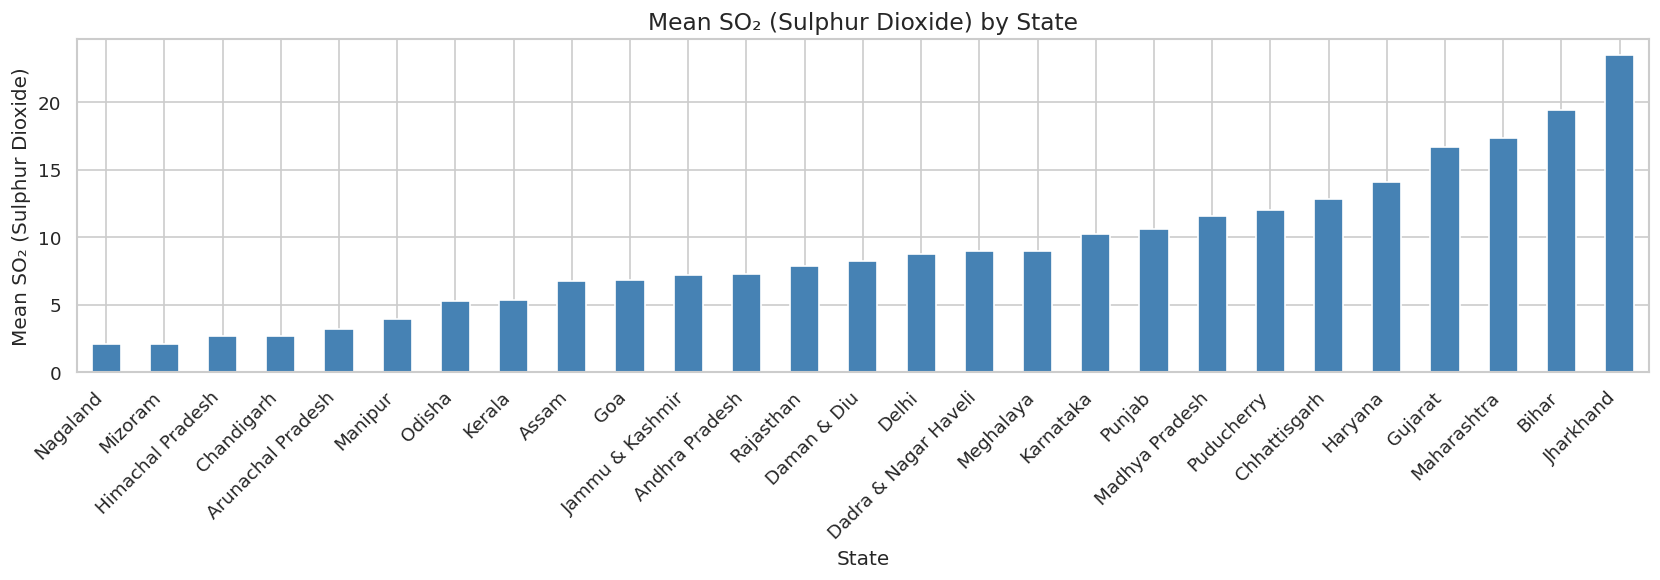

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
(df.groupby('state')['so2']
   .mean()
   .sort_values()
   .plot.bar(color='steelblue', ax=ax))
ax.set_title("Mean SO₂ (Sulphur Dioxide) by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean SO₂ (Sulphur Dioxide)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


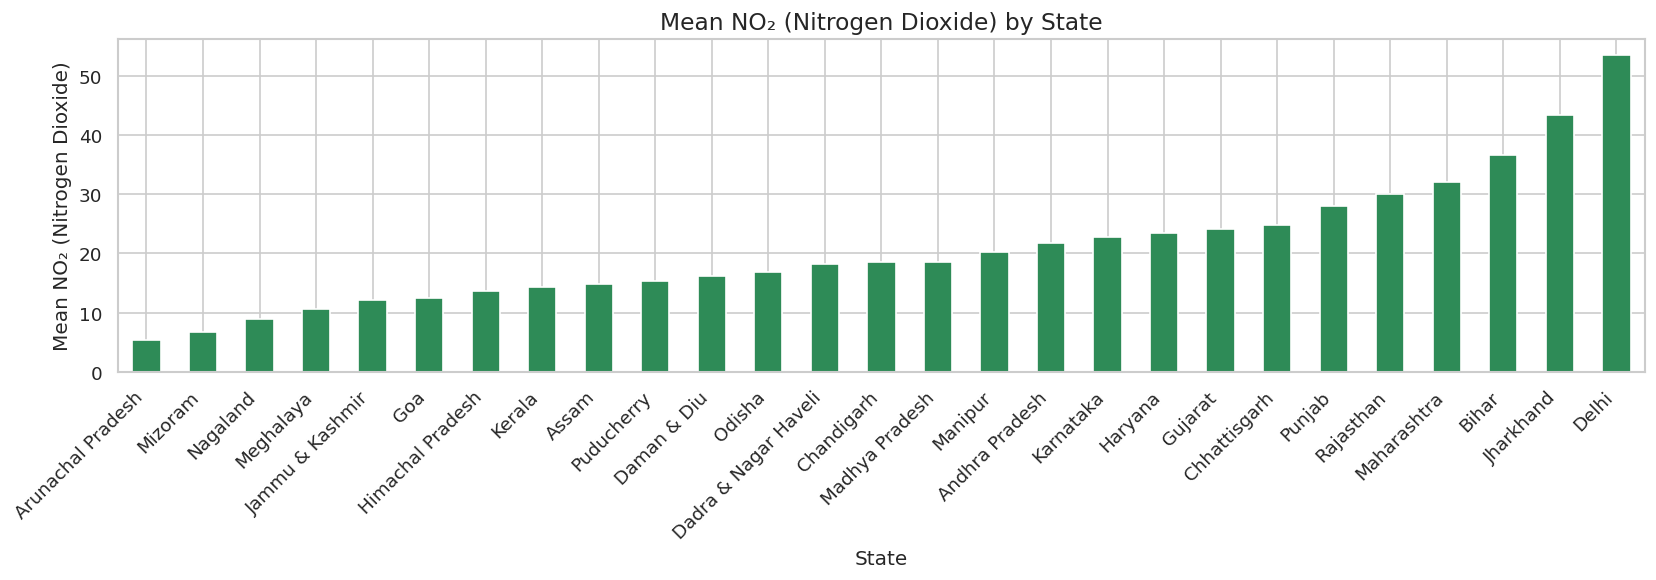

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
(df.groupby('state')['no2']
   .mean()
   .sort_values()
   .plot.bar(color='seagreen', ax=ax))
ax.set_title("Mean NO₂ (Nitrogen Dioxide) by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean NO₂ (Nitrogen Dioxide)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


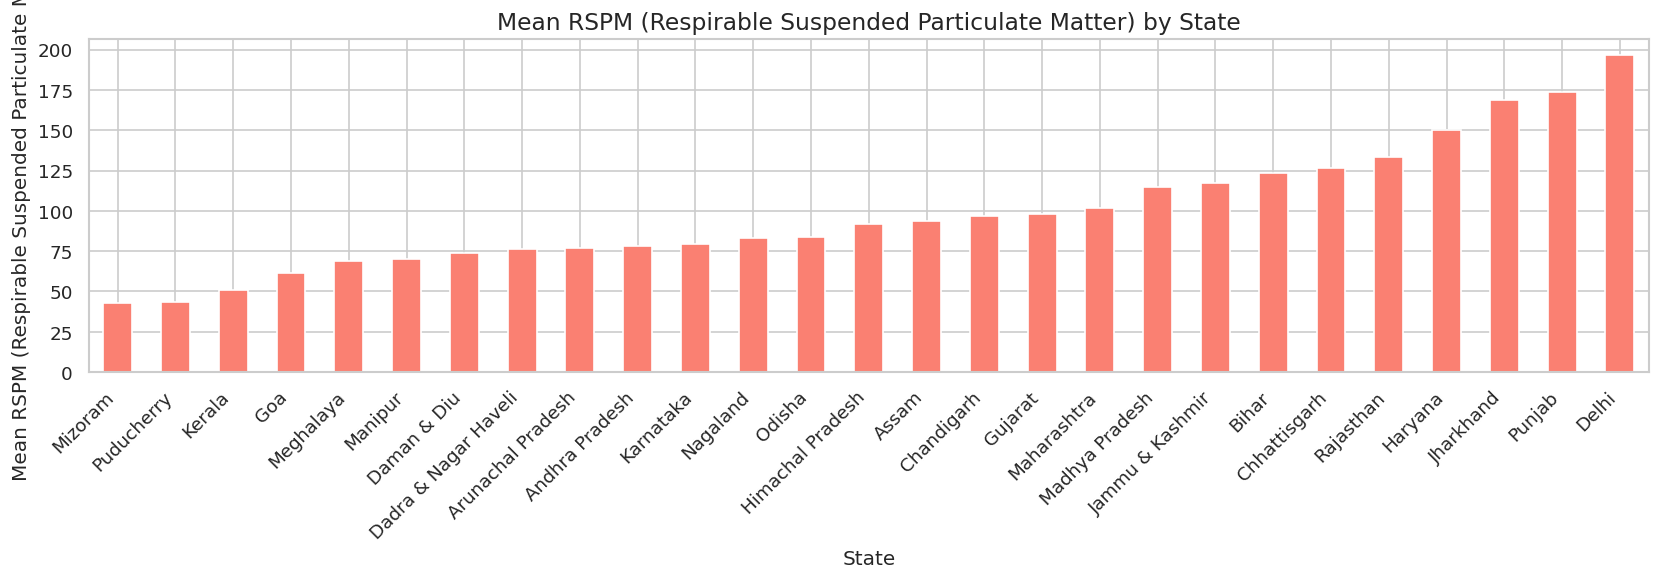

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
(df.groupby('state')['rspm']
   .mean()
   .sort_values()
   .plot.bar(color='salmon', ax=ax))
ax.set_title("Mean RSPM (Respirable Suspended Particulate Matter) by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean RSPM (Respirable Suspended Particulate Matter)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


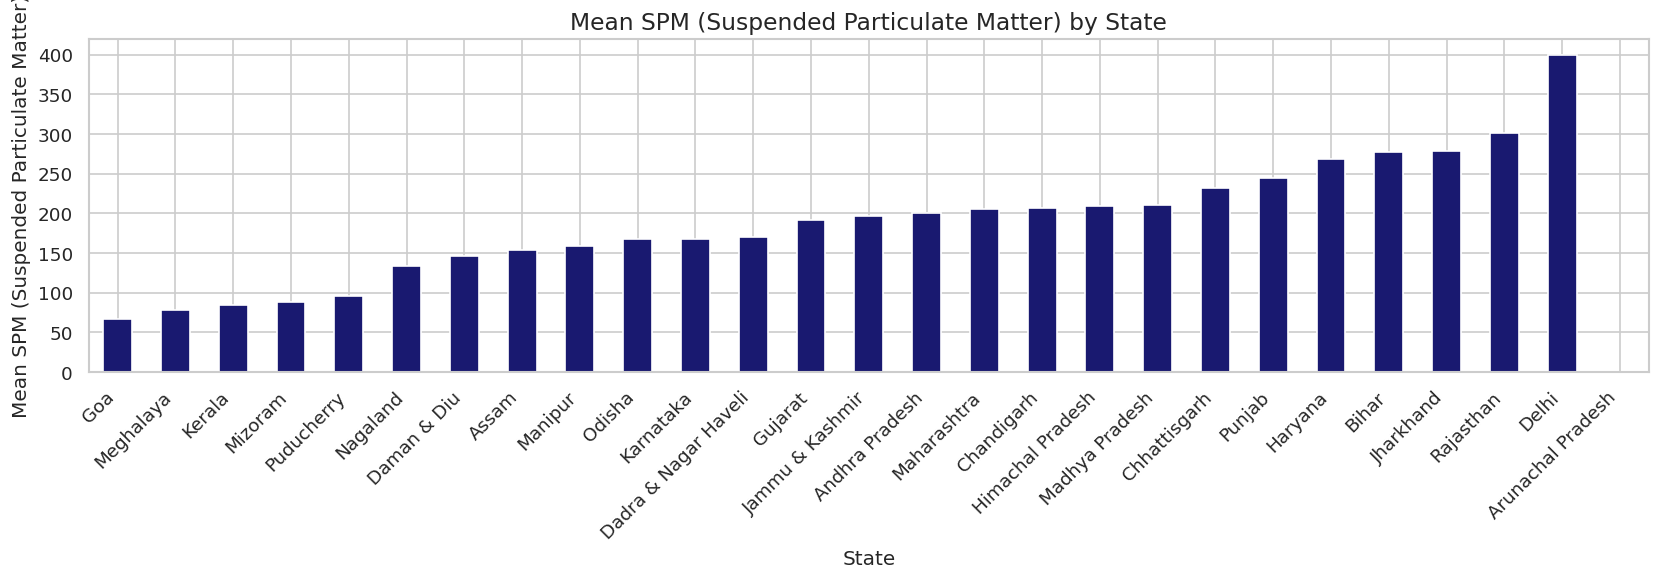

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
(df.groupby('state')['spm']
   .mean()
   .sort_values()
   .plot.bar(color='midnightblue', ax=ax))
ax.set_title("Mean SPM (Suspended Particulate Matter) by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean SPM (Suspended Particulate Matter)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


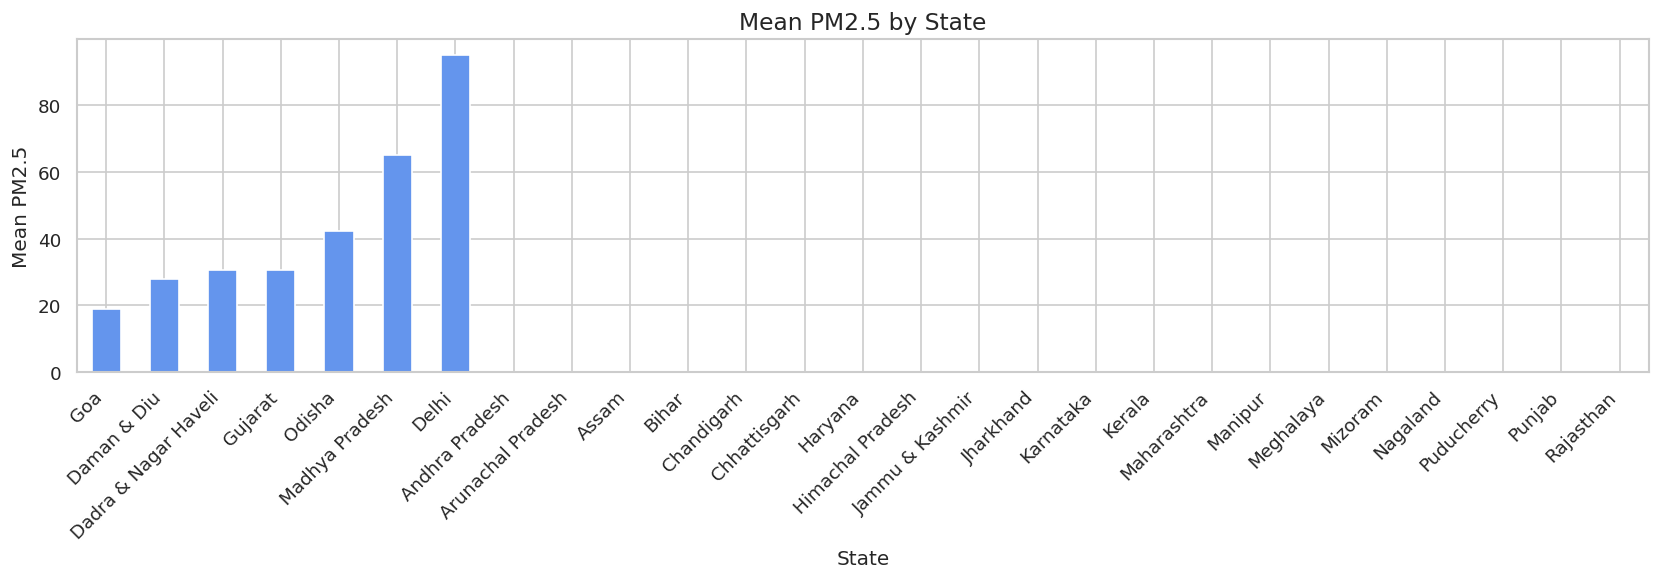

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
(df.groupby('state')['pm2_5']
   .mean()
   .sort_values()
   .plot.bar(color='cornflowerblue', ax=ax))
ax.set_title("Mean PM2.5 by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean PM2.5")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5. Feature Selection & Null Handling

We retain only the columns needed for AQI computation.  
Categorical columns (`location`, `type`) are filled with their mode.  
Remaining numeric nulls are filled with **0** , appropriate here because a missing
pollutant reading typically means the pollutant was below the detection threshold.


In [11]:
# Keeping only the relevant columns
data = df[["state", "location", "type", "so2", "no2", "rspm", "spm", "pm2_5"]].copy()

# Filling categorical nulls with mode
data['location'] = data['location'].fillna(data['location'].mode()[0])
data['type']     = data['type'].fillna(data['type'].mode()[0])

# Filling numeric nulls with 0
data.fillna(0, inplace=True)

print(f"Shape after cleaning: {data.shape}")
print("Remaining nulls:", data.isnull().sum().sum())
data.head()


Shape after cleaning: (337018, 8)
Remaining nulls: 0


,state,location,type,so2,no2,rspm,spm,pm2_5
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,0.0,0.0,0.0
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,0.0,0.0,0.0
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,0.0,0.0,0.0
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,0.0,0.0,0.0
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,0.0,0.0,0.0


## 6. AQI Sub-index Computation

India's AQI is calculated from four pollutant sub-indices using the **piecewise linear
interpolation** formula defined by the Central Pollution Control Board (CPCB).
Each sub-index maps a raw concentration to a 0–500 scale.


### 6.1 SO₂ Sub-index

In [12]:
def cal_SOi(so2):
    """Compute the SO2 sub-index using CPCB breakpoints (µg/m³ → AQI scale)."""
    if so2 <= 40:
        return so2 * (50 / 40)
    elif so2 <= 80:
        return 50 + (so2 - 40) * (50 / 40)
    elif so2 <= 380:
        return 100 + (so2 - 80) * (100 / 300)
    elif so2 <= 800:
        return 200 + (so2 - 380) * (100 / 420)
    elif so2 <= 1600:
        return 300 + (so2 - 800) * (100 / 800)
    else:
        return 400 + (so2 - 1600) * (100 / 800)

data['SOi'] = data['so2'].apply(cal_SOi)
data[['so2', 'SOi']].head()


,so2,SOi
0,4.8,6.000
1,3.1,3.875
2,6.2,7.750
3,6.3,7.875
4,4.7,5.875


### 6.2 NO₂ Sub-index

In [13]:
def cal_Noi(no2):
    """Compute the NO2 sub-index using CPCB breakpoints (µg/m³ → AQI scale)."""
    if no2 <= 40:
        return no2 * 50 / 40
    elif no2 <= 80:
        return 50 + (no2 - 40) * (50 / 40)
    elif no2 <= 180:
        return 100 + (no2 - 80) * (100 / 100)
    elif no2 <= 280:
        return 200 + (no2 - 180) * (100 / 100)
    elif no2 <= 400:
        return 300 + (no2 - 280) * (100 / 120)
    else:
        return 400 + (no2 - 400) * (100 / 120)

data['Noi'] = data['no2'].apply(cal_Noi)
data[['no2', 'Noi']].head()


,no2,Noi
0,17.4,21.750
1,7.0,8.750
2,28.5,35.625
3,14.7,18.375
4,7.5,9.375


### 6.3 RSPM Sub-index

In [14]:
def cal_RSPMI(rspm):
    """Compute the RSPM sub-index using CPCB breakpoints (µg/m³ → AQI scale)."""
    if rspm <= 30:
        return rspm * 50 / 30
    elif rspm <= 60:
        return 50 + (rspm - 30) * 50 / 30
    elif rspm <= 90:
        return 100 + (rspm - 60) * 100 / 30
    elif rspm <= 120:
        return 200 + (rspm - 90) * 100 / 30
    elif rspm <= 250:
        return 300 + (rspm - 120) * (100 / 130)
    else:
        return 400 + (rspm - 250) * (100 / 130)

data['Rpi'] = data['rspm'].apply(cal_RSPMI)
data[['rspm', 'Rpi']].head()


,rspm,Rpi
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


### 6.4 SPM Sub-index

In [15]:
def cal_SPMi(spm):
    """Compute the SPM sub-index using CPCB breakpoints (µg/m³ → AQI scale)."""
    if spm <= 50:
        return spm * 50 / 50
    elif spm <= 100:
        return 50 + (spm - 50) * (50 / 50)
    elif spm <= 250:
        return 100 + (spm - 100) * (100 / 150)
    elif spm <= 350:
        return 200 + (spm - 250) * (100 / 100)
    elif spm <= 430:
        return 300 + (spm - 350) * (100 / 80)
    else:
        return 400 + (spm - 430) * (100 / 430)

data['SPMi'] = data['spm'].apply(cal_SPMi)
data[['spm', 'SPMi']].head()


,spm,SPMi
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


### 6.5 Overall AQI

In [16]:
def cal_aqi(si, ni, rspmi, spmi):
    """AQI is the maximum of all pollutant sub-indices (dominant pollutant method)."""
    return max(si, ni, rspmi, spmi)

data['AQI'] = data.apply(
    lambda row: cal_aqi(row['SOi'], row['Noi'], row['Rpi'], row['SPMi']), axis=1
)

# Map AQI score to a human-readable category
def aqi_category(x):
    if x <= 50:
        return "Good"
    elif x <= 100:
        return "Moderate"
    elif x <= 200:
        return "Poor"
    elif x <= 300:
        return "Unhealthy"
    elif x <= 400:
        return "Very Unhealthy"
    else:
        return "Hazardous"

data['AQI_Range'] = data['AQI'].apply(aqi_category)

data[['state', 'SOi', 'Noi', 'Rpi', 'SPMi', 'AQI', 'AQI_Range']].head(10)


,state,SOi,Noi,Rpi,SPMi,AQI,AQI_Range
0,Andhra Pradesh,6.000,21.750,0.0,0.0,21.750,Good
1,Andhra Pradesh,3.875,8.750,0.0,0.0,8.750,Good
2,Andhra Pradesh,7.750,35.625,0.0,0.0,35.625,Good
3,Andhra Pradesh,7.875,18.375,0.0,0.0,18.375,Good
4,Andhra Pradesh,5.875,9.375,0.0,0.0,9.375,Good
5,Andhra Pradesh,8.000,32.125,0.0,0.0,32.125,Good
6,Andhra Pradesh,6.750,21.375,0.0,0.0,21.375,Good
7,Andhra Pradesh,5.875,10.875,0.0,0.0,10.875,Good
8,Andhra Pradesh,5.250,28.750,0.0,0.0,28.750,Good
9,Andhra Pradesh,5.000,11.125,0.0,0.0,11.125,Good


### 6.6 AQI Category Distribution

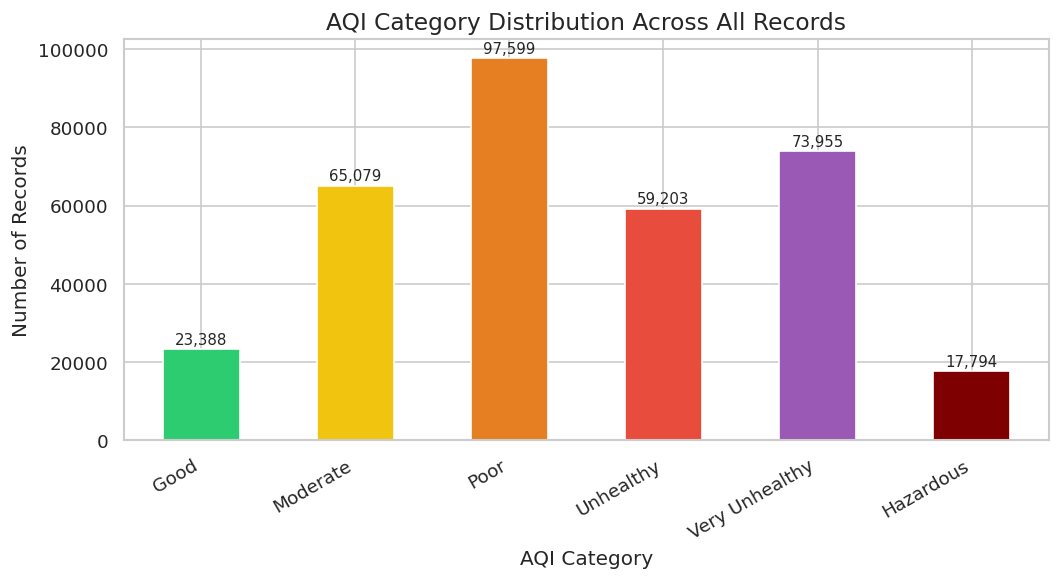


Category breakdown:
AQI_Range
Good              23388
Moderate          65079
Poor              97599
Unhealthy         59203
Very Unhealthy    73955
Hazardous         17794


In [17]:
category_order = ["Good", "Moderate", "Poor", "Unhealthy", "Very Unhealthy", "Hazardous"]
category_colors = {
    "Good":           "#2ecc71",
    "Moderate":       "#f1c40f",
    "Poor":           "#e67e22",
    "Unhealthy":      "#e74c3c",
    "Very Unhealthy": "#9b59b6",
    "Hazardous":      "#7f0000",
}

counts = data['AQI_Range'].value_counts().reindex(category_order, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
counts.plot.bar(color=[category_colors[c] for c in counts.index], ax=ax, edgecolor='white')
ax.set_title("AQI Category Distribution Across All Records")
ax.set_xlabel("AQI Category")
ax.set_ylabel("Number of Records")
plt.xticks(rotation=30, ha='right')

# Annotate counts
for i, v in enumerate(counts):
    ax.text(i, v + 500, f"{v:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nCategory breakdown:")
print(counts.to_string())


## 7. Model Training

We use **Elastic Net** regression : a linear model that combines L1 (Lasso) and L2 (Ridge)
penalties. It is well-suited for datasets with correlated features (e.g., multiple
correlated pollutant sub-indices).

**Features (X):** SOi, Noi, Rpi, SPMi  
**Target (y):** AQI


In [18]:
X = data[['SOi', 'Noi', 'Rpi', 'SPMi']]
y = data['AQI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")


Training samples : 269,614
Test samples     : 67,404


### 7.1 Hyperparameter Tuning with GridSearchCV

We search over a log-scale grid of `alpha` values and a range of `l1_ratio` values.  
`scoring='neg_mean_squared_error'` with 10-fold CV ensures robust selection.


In [19]:
param_grid = {
    'alpha':    np.logspace(-5, 2, 8),   # regularisation strength
    'l1_ratio': [0.2, 0.4, 0.6, 0.8],   # L1 vs L2 mix (0 = Ridge, 1 = Lasso)
}

grid_search = GridSearchCV(
    estimator=ElasticNet(),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=10,
    n_jobs=-1,       # use all available CPU cores
    refit=True,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV MSE    : {abs(grid_search.best_score_):.4f}")


Best parameters: {'alpha': np.float64(0.1), 'l1_ratio': 0.2}
Best CV MSE    : 1967.4242


### 7.2 Final Model

In [20]:
# Train the final model with the best hyperparameters found above
model = ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=42)
model.fit(X_train, y_train)


ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=42)

## 8. Model Evaluation


In [21]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


R²   : 0.8617
MAE  : 31.1531
MSE  : 1939.4372
RMSE : 44.0390


### 8.1 Feature Coefficients

In [22]:
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_,
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

# Features with meaningful contribution (|coeff| > 0.01)
important = coef_df[coef_df['Coefficient'].abs() > 0.01]['Feature'].tolist()
print(f"\nImportant features: {important}")


Feature  Coefficient
    Rpi     0.760333
    Noi     0.413577
    SOi     0.360946
   SPMi     0.298404

Important features: ['Rpi', 'Noi', 'SOi', 'SPMi']


### 8.2 Predicted vs Actual

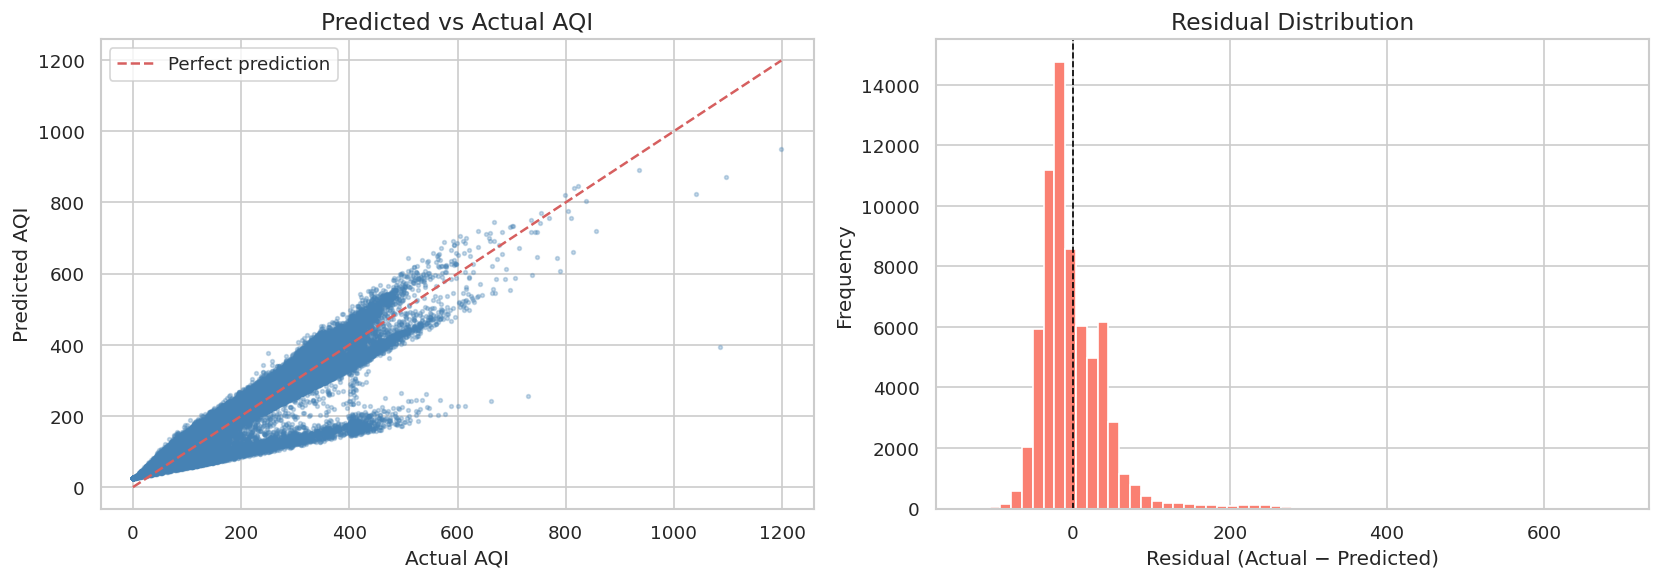

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual AQI")
axes[0].set_ylabel("Predicted AQI")
axes[0].set_title("Predicted vs Actual AQI")
axes[0].legend()

# Residual distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()


## 9. Conclusion

The Elastic Net model achieves a strong fit on this dataset, with an R² close to 1.0
given that AQI is a deterministic function of the same four sub-indices used as features.

**Key takeaways:**
- The AQI is dominated by whichever pollutant sub-index is highest, this is by CPCB design.
- RSPM and SPM are historically the dominant contributors to poor air quality in Indian cities.
- Elastic Net's combined L1/L2 penalty handled the moderate multi-collinearity between
  pollutant sub-indices without overfitting.

**Potential extensions:**
- Include temporal features (`year`, `month`) to capture seasonal trends.
- Train separate models per region or station type.
- Try tree-based models (XGBoost, Random Forest) for non-linear relationships.
